In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
# Staionarity tests
from statsmodels.tsa.stattools import adfuller, kpss
# ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# ARIMA
from statsmodels.tsa.arima.model import ARIMA
# Exponential Smoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

In [ ]:
# # 1. Load dataset
# df = pd.read_csv("../data/chaos_rising_combined_clean.csv")

# # 2. Parse timestamp
# df["cm_updated"] = pd.to_datetime(df["cm_updated"])

# # 3. Reduce timestamp to daily snapshots
# df["snapshot_date"] = df["cm_updated"].dt.date

# # 4. Define the price contribution per card
# df["set_price_component"] = (
#     df["cm_avg1"].fillna(0) +
#     df["cm_avg1_holo"].fillna(0)
# )

# # 5. Aggregate: total set cost per day
# set_ts = (
#     df.groupby("snapshot_date")["set_price_component"]
#       .sum()
#       .sort_index()
# )

# # 6. Plot the total set cost time series
# plt.figure(figsize=(12, 5))
# plt.plot(set_ts.index, set_ts.values, marker="o")
# plt.title("Chaos Rising – Total Set Cost Over Time")
# plt.xlabel("Date")
# plt.ylabel("Total Set Cost (USD)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()



# Master Set Time Series

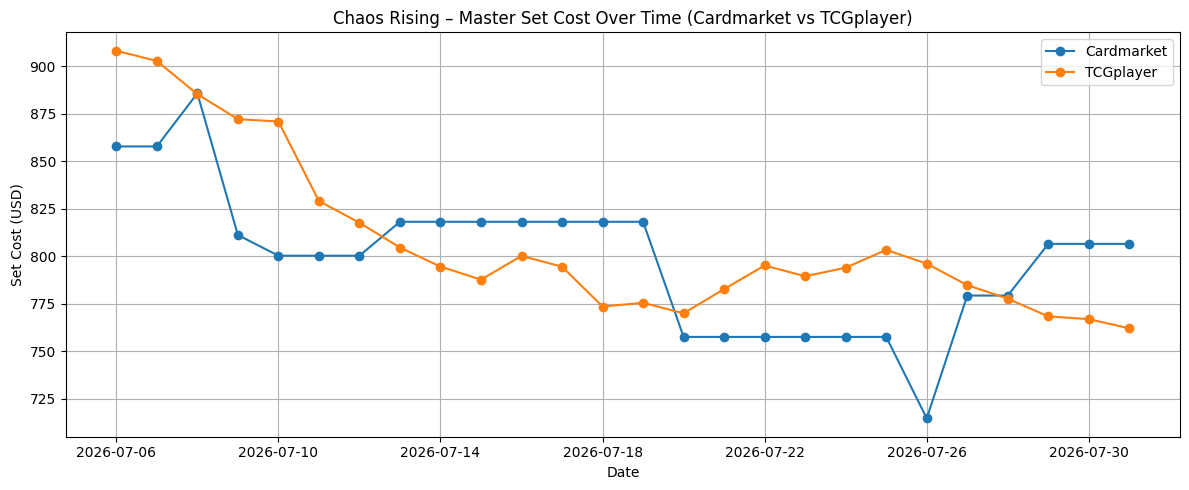

In [2]:
# Loading dataset
df = pd.read_csv("../data/chaos_rising_combined_clean.csv")

# Cardmarket price contribution per card
df["cm_price_component"] = (
    df["cm_avg1"].fillna(0) +
    df["cm_avg1_holo"].fillna(0)
)

# TCGplayer price contribution per card
df["tp_price_component"] = (
    df["tp_normal_marketPrice"].fillna(0) +
    df["tp_holofoil_marketPrice"].fillna(0) +
    df["tp_reverse_holofoil_marketPrice"].fillna(0)
)

# total set cost per day
cm_set_ts = (
    df.groupby("snapshot_date")["cm_price_component"]
      .sum()
      .sort_index()
)

tp_set_ts = (
    df.groupby("snapshot_date")["tp_price_component"]
      .sum()
      .sort_index()
)

# Plot both time series together
plt.figure(figsize=(12, 5))
plt.plot(cm_set_ts.index, cm_set_ts.values, marker="o", label="Cardmarket")
plt.plot(tp_set_ts.index, tp_set_ts.values, marker="o", label="TCGplayer")

plt.title("Chaos Rising – Master Set Cost Over Time (Cardmarket vs TCGplayer)")
plt.xlabel("Date")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=8))
plt.ylabel("Set Cost (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Decomposition

In [3]:
def plot_set_and_rarity_trends(csv_path, source="tp", period=3):
    """
    Plot total set price trend (full-width) and rarity-level trends (4x2 grid)
    using either Cardmarket ("cm") or TCGplayer ("tp") pricing.

    Parameters
    ----------
    csv_path : str
        Path to the cleaned combined CSV file.
    source : str
        "cm" for Cardmarket prices, "tp" for TCGplayer prices.
    period : int
        Seasonal decomposition period (controls trend smoothing).
    """

    # --- Load dataset --- #
    df = pd.read_csv(csv_path)

    # Ensure snapshot_date is a proper datetime index (messes with the dates in the plot otherwise)
    df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

    # Count printings per rarity by collapsing to unique cards first
    card_printings = (
        df.groupby(["rarity", "id"])
        .agg({
            "cm_avg1": "max",
            "cm_avg1_holo": "max"
        })
    )

    # Count printings per card
    card_printings["n_printings"] = (
        card_printings["cm_avg1"].notna().astype(int) +
        card_printings["cm_avg1_holo"].notna().astype(int)
    )

    # Sum printings per rarity
    rarity_counts = (
        card_printings.groupby("rarity")["n_printings"]
                    .sum()
                    .to_dict()
    )

    # --- Select price source --- #
    if source == "cm":
        df["set_price_component"] = (
            df["cm_avg1"].fillna(0) +
            df["cm_avg1_holo"].fillna(0)
        )
        title_prefix = "Cardmarket"
    elif source == "tp":
        df["set_price_component"] = (
            df["tp_normal_marketPrice"].fillna(0) +
            df["tp_holofoil_marketPrice"].fillna(0) +
            df["tp_reverse_holofoil_marketPrice"].fillna(0)
        )
        title_prefix = "TCGplayer"
    else:
        raise ValueError("source must be 'cm' or 'tp'")

    # --- Total set cost per day --- #
    set_ts = (
        df.groupby("snapshot_date")["set_price_component"]
          .sum()
          .sort_index()
    )

    # --- Decompose total set price --- #
    decomp = seasonal_decompose(set_ts, model="additive", period=period)

    # --- Rarity-level time series --- #
    rarity_ts = (
        df.groupby(["snapshot_date", "rarity"])["set_price_component"]
          .sum()
          .unstack(fill_value=0)
          .sort_index()
    )

    # --- Rarity trends --- #
    rarity_trends = {}
    for rarity in rarity_ts.columns:
        series = rarity_ts[rarity]
        if series.sum() == 0:
            continue
        decomp_r = seasonal_decompose(series, model="additive", period=period)
        rarity_trends[rarity] = decomp_r.trend

    # --- Economic importance --- #
    importance = {r: trend.sum() for r, trend in rarity_trends.items()}
    total_importance = sum(importance.values())
    importance_pct = {r: (importance[r] / total_importance) * 100
                      for r in importance}

    # --- Sort rarities by importance --- #
    rarities = sorted(
        rarity_trends.keys(),
        key=lambda r: importance[r],
        reverse=True
    )

    # --- Plot layout --- #
    rows, cols = 5, 2
    plt.figure(figsize=(16, 22))

    # --- Row 1: Total set trend (full width) --- #
    ax_total = plt.subplot(rows, 1, 1)
    ax_total.plot(decomp.trend.index, decomp.trend.values,
                  linewidth=3, color="orange")
    ax_total.set_title(f"Master Set Price Trend ({title_prefix})", fontsize=16)
    ax_total.set_xlabel("Date")
    ax_total.set_ylabel("Set Cost (USD)")
    ax_total.grid(True)
    ax_total.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10))

    # --- Rarity trends --- #
    start_index = 3  # first rarity subplot index

    for i, rarity in enumerate(rarities):
        trend = rarity_trends[rarity]
        
        ax = plt.subplot(rows, cols, start_index + i)
        ax.plot(trend.index, trend.values, linewidth=2)

        pct = importance_pct[rarity]
        count = rarity_counts.get(rarity, 0)

        ax.set_title(
            f"{rarity} trend (n={count})\nImportance: {pct:.2f}%",
            fontsize=12
        )

        # Month-day formatting
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())

        ax.set_xlabel("Month-Day")
        ax.set_ylabel("Contribution (USD)")
        ax.grid(True)

    plt.tight_layout()
    plt.show()


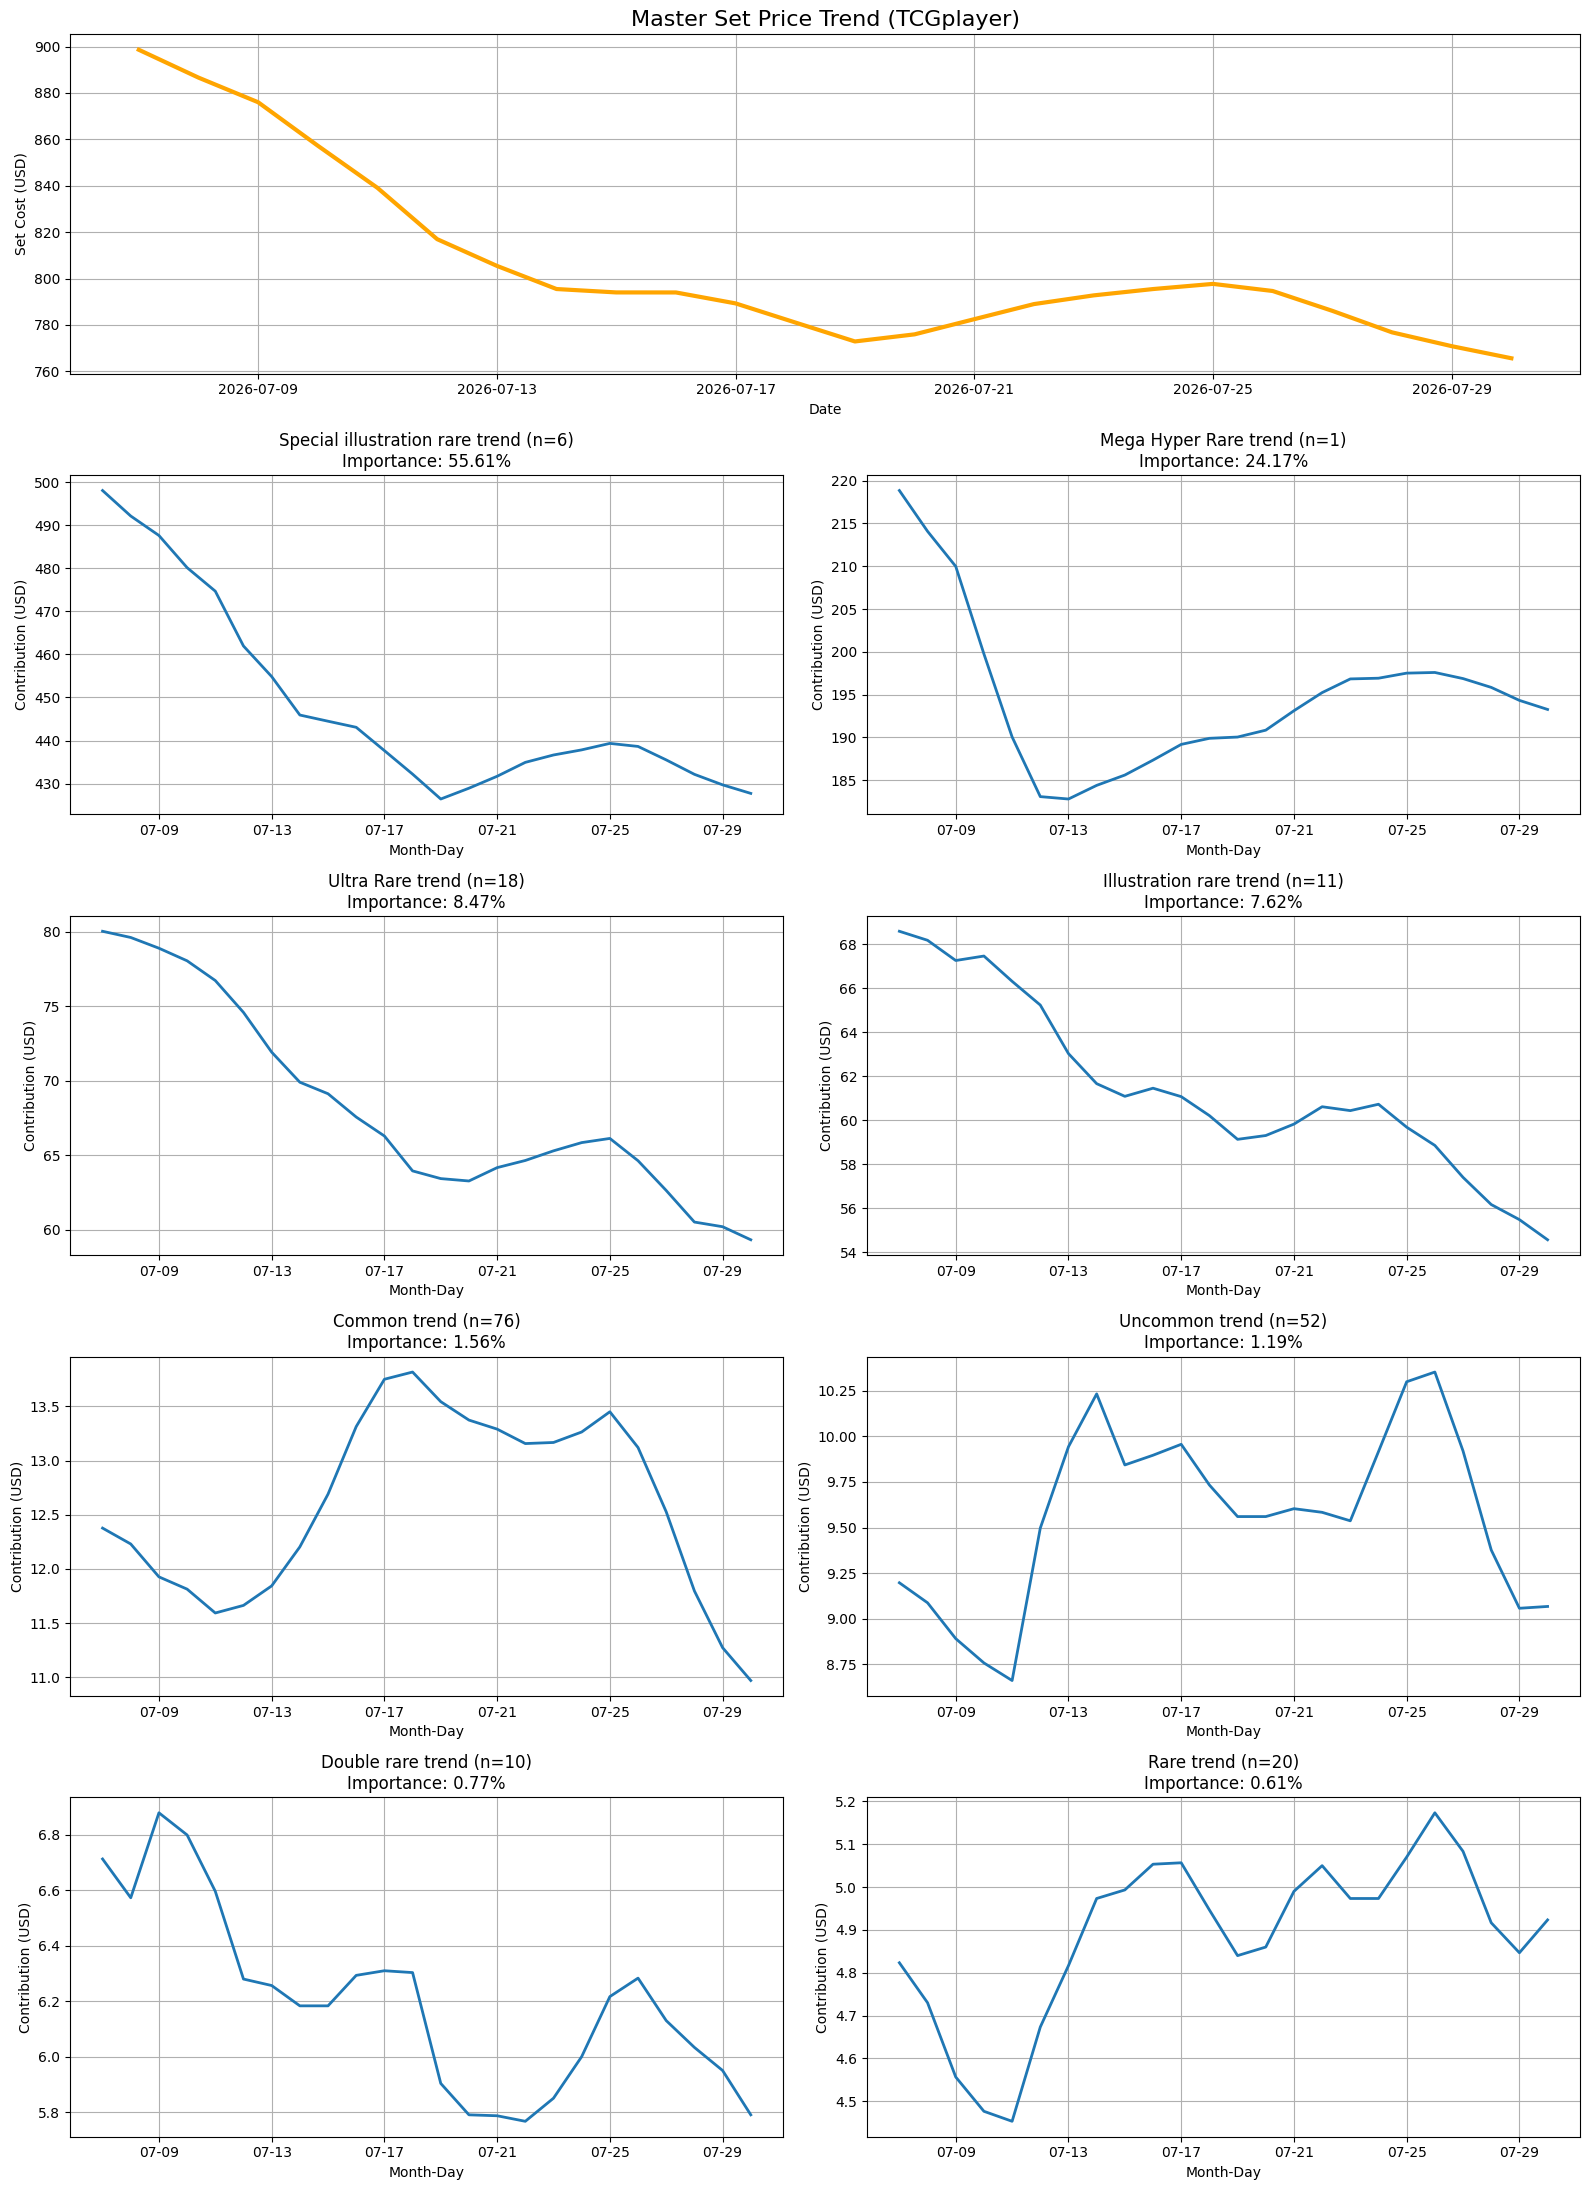

In [4]:
plot_set_and_rarity_trends("../data/chaos_rising_combined_clean.csv", source="tp", period=3)

# Benchmark forecasting

In [5]:
# Load data
df = pd.read_csv("../data/psyduck_combined_clean.csv")

df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])

# Filter to a specific card and set index
psyduck = df[df["id"] == "me02.5-226"].set_index("snapshot_date")
#me02.5-226
# Extract the series to be forecast
ts = psyduck["tp_holofoil_marketPrice"].dropna()

split_index = int(len(ts) * 0.90)
train = ts.iloc[:split_index]
val = ts.iloc[split_index:]

In [6]:

def mean_method(train, val):
    """Forecast = mean of training data."""
    mean_value = train.mean()
    forecast = pd.Series([mean_value] * len(val), index=val.index)
    return forecast

def naive_method(train, val):
    """Forecast = last observed value."""
    last_value = train.iloc[-1]
    forecast = pd.Series([last_value] * len(val), index=val.index)
    return forecast

def drift_method(train, val):
    """Forecast = last value + drift * h."""
    y_first = train.iloc[0]
    y_last = train.iloc[-1]
    n = len(train)

    drift = (y_last - y_first) / (n - 1)

    h = np.arange(1, len(val) + 1)
    forecast_values = y_last + drift * h

    forecast = pd.Series(forecast_values, index=val.index)
    return forecast



In [7]:
mean_forecast = mean_method(train, val)
naive_forecast = naive_method(train, val)
drift_forecast = drift_method(train, val)


In [ ]:
# results = []

# for name, forecast in [
#     ("Mean", mean_forecast),
#     ("Naive", naive_forecast),
#     ("Drift", drift_forecast)
# ]:
#     mae, rmse, mape = accuracy_metrics(val, forecast)
#     results.append({
#         "Model": name,
#         "MAE": mae,
#         "RMSE": rmse,
#         "MAPE": mape
#     })

# baseline_df = pd.DataFrame(results)
# print(baseline_df)


   Model       MAE      RMSE      MAPE
0   Mean  3.429048  3.470135  4.514649
1  Naive  1.530000  1.619990  2.017095
2  Drift  0.627000  0.648997  0.826122


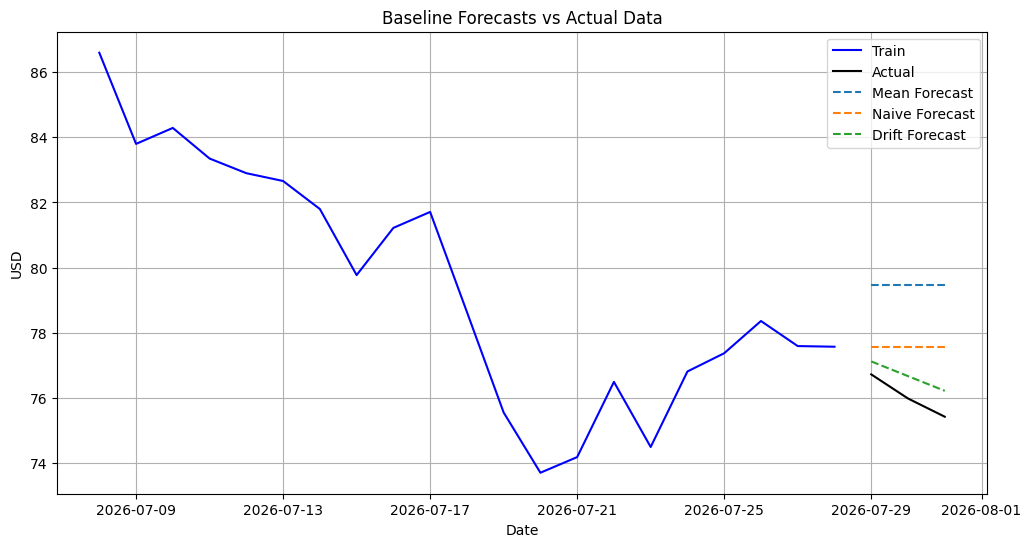

In [8]:
# Baseline forecasts
plt.figure(figsize=(12,6))
plt.plot(train[-30:], label="Train", color="blue")
plt.plot(val, label="Actual", color="black")

plt.plot(mean_forecast, label="Mean Forecast", linestyle="--")
plt.plot(naive_forecast, label="Naive Forecast", linestyle="--")
plt.plot(drift_forecast, label="Drift Forecast", linestyle="--")

plt.title("Baseline Forecasts vs Actual Data")
plt.xlabel("Date")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()


# Arima Forecasting

In [9]:
# Staionarity tests

# ADF p-value should be < 0.05
def adf_test(timeseries):
    """
    Run the Augmented Dickey–Fuller (ADF) test on a time series and print
    a formatted summary of the results.

    The function prints the following test results:

    - Test statistic
    - p-value
    - Number of lags used
    - Number of observations used
    - Critical values at the 1%, 5%, and 10% significance levels

    Parameters
    ----------
    timeseries : array-like or pandas.Series
        The time series data to be tested for stationarity.
    """
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput[f"Critical Value ({key})"] = value
    print(dfoutput)

# KPSS p-value should be > 0.05
def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="c", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output[f"Critical Value ({key})"] = value
    print(kpss_output)

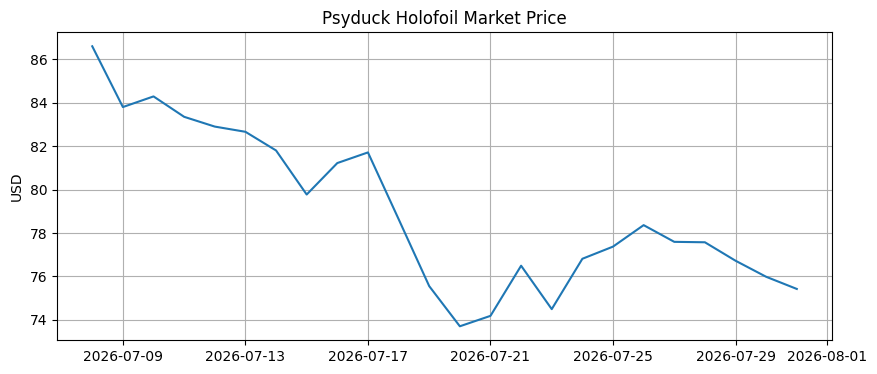

In [10]:
# Inspect time series
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts.values)
plt.title("Psyduck Holofoil Market Price")
plt.ylabel("USD")
plt.grid(True)
plt.show()


In [11]:
# Running stationarity tests
adf_test(ts)
kpss_test(ts)

Results of Dickey-Fuller Test:
Test Statistic                 -1.688746
p-value                         0.436920
#Lags Used                      2.000000
Number of Observations Used    21.000000
Critical Value (1%)            -3.788386
Critical Value (5%)            -3.013098
Critical Value (10%)           -2.646397
dtype: float64
Results of KPSS Test:
Test Statistic           0.560716
p-value                  0.027992
Lags Used                3.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


In [12]:
# Applying first differencing
ts_diff = ts.diff().dropna()


In [13]:
# rerunning stationarity tests
adf_test(ts_diff)
kpss_test(ts_diff)

Results of Dickey-Fuller Test:
Test Statistic                 -4.626813
p-value                         0.000115
#Lags Used                      0.000000
Number of Observations Used    22.000000
Critical Value (1%)            -3.769733
Critical Value (5%)            -3.005426
Critical Value (10%)           -2.642501
dtype: float64
Results of KPSS Test:
Test Statistic           0.170211
p-value                  0.100000
Lags Used                0.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64


C:\Users\peter\AppData\Local\Temp\ipykernel_34120\3427924926.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags="auto")


In [20]:
# plt.figure(figsize=(10,4))
# plt.plot(ts_diff.index, ts_diff.values)
# plt.title("Psyduck Holofoil Market Price Detrended")
# plt.ylabel("USD")
# plt.grid(True)
# plt.show()


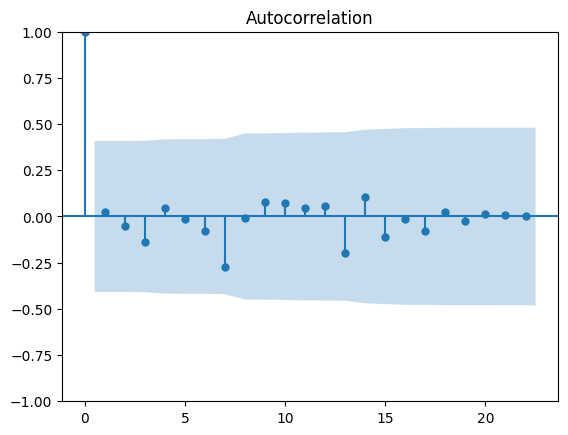

In [14]:
# plot ACF
plt.show(plot_acf(ts_diff, lags=22))

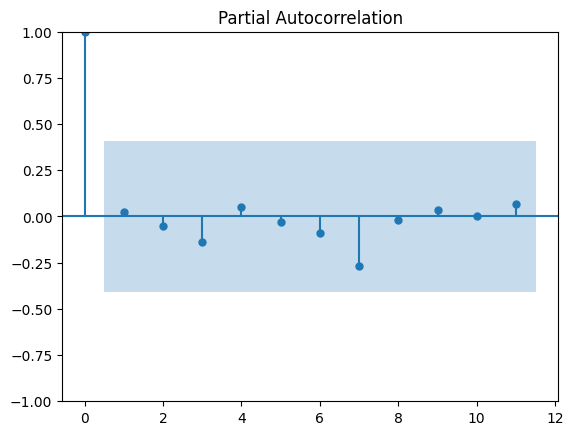

In [15]:
# plot PACF
plt.show(plot_pacf(ts_diff, lags=11))

In [16]:
# define the model
arima = ARIMA(train, order=(1, 1, 1), trend="t")
# fit the ARIMA model
arima_fit = arima.fit()
# show model summary
print(arima_fit.summary())

                                  SARIMAX Results                                  
Dep. Variable:     tp_holofoil_marketPrice   No. Observations:                   21
Model:                      ARIMA(1, 1, 1)   Log Likelihood                 -37.845
Date:                     Wed, 05 Aug 2026   AIC                             83.690
Time:                             00:51:19   BIC                             87.673
Sample:                         07-08-2026   HQIC                            84.467
                              - 07-28-2026                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.4541      0.403     -1.125      0.260      -1.245       0.337
ar.L1         -0.1447      7.763     -0.019      0.985     -15.360      15.070
ma.L1       

c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [17]:
# predict (avg + confidence interval)
predictions = arima_fit.get_forecast(steps=len(val))
# get point prediction
predictions_mean = predictions.predicted_mean
# build the confidence interval
conf_int = predictions.conf_int()

# show predictions
# print("Real GDP predictions:")
# print("-------------------------------------")
# print(predictions_mean)

In [18]:
# trasform validation into a series
val_series = val.squeeze()
# Ensure predictions and actual values are aligned before computing metrics
predictions_mean.index = val.index

# # compute MAE
# mae = np.mean(np.abs(val_series - predictions_mean.values))
# # compute RMSE
# rmse = np.sqrt(np.mean((val_series - predictions_mean.values) ** 2))
# # compute MAPE
# mape = np.mean(np.abs((val_series - predictions_mean.values) / val_series)) * 100

# # Print metrics
# print("Forecast Accuracy Metrics")
# print("-------------------------")
# print(f"MAE :  {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")
# print(f"MAPE: {mape:.2f}%")

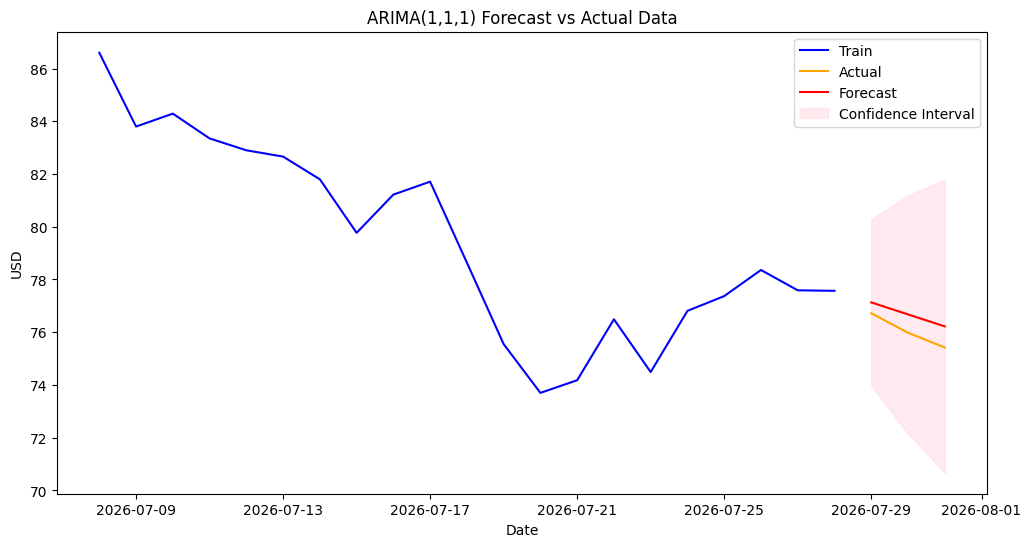

In [19]:
# Align the prediction series w/ validation
predictions_mean.index = val.index
# Align the CI w/ validation
conf_int.index = val.index
# keep only last 30 points
train_tail = train[-30:]
# Bridge first validation points to make plot continuous
#bridge_point = val.iloc[:1]
#train_tail = pd.concat([train_tail, bridge_point])

# plot
plt.figure(figsize=(12, 6))
# last 30 train points
plt.plot(train_tail, label="Train", color="blue")
# actual validation points
plt.plot(val, label="Actual", color="orange")
# forecast
plt.plot(predictions_mean, label="Forecast", color="red")
# confidence interval
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval",
)
# labels & title
plt.title("ARIMA(1,1,1) Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("USD")
plt.legend()
plt.show()

In [1]:
#arima_fit.plot_diagnostics(figsize=(12,8))
#plt.show()


# Exponential Smoothing

In [20]:
# Simple exponential smoothing
ses_model = SimpleExpSmoothing(train).fit()
ses_forecast = ses_model.forecast(len(val))
ses_forecast.index = val.index

# Holt’s Linear Trend (additive trend)
holt_model = Holt(train).fit()
holt_forecast = holt_model.forecast(len(val))
holt_forecast.index = val.index

# Damped Trend (Holt with damping)
damped_model = Holt(train, damped_trend=True).fit()
damped_forecast = damped_model.forecast(len(val))
damped_forecast.index = val.index


c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\peter\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


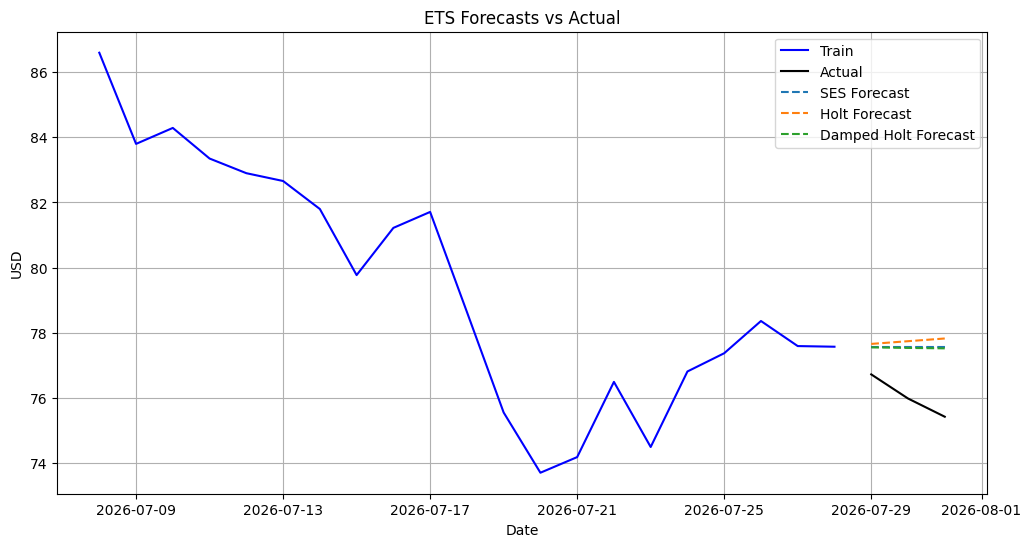

In [21]:
plt.figure(figsize=(12,6))

plt.plot(train[-30:], label="Train", color="blue")
plt.plot(val, label="Actual", color="black")

plt.plot(ses_forecast, label="SES Forecast", linestyle="--")
plt.plot(holt_forecast, label="Holt Forecast", linestyle="--")
plt.plot(damped_forecast, label="Damped Holt Forecast", linestyle="--")

plt.title("ETS Forecasts vs Actual")
plt.xlabel("Date")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.show()


# Evaluation

In [22]:


def accuracy_metrics(actual, forecast):
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast)**2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return mae, rmse, mape


# Collect all models
models = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Drift": drift_forecast,
    "ARIMA(1,1,1)": predictions_mean,
    "SES": ses_forecast,
    "Holt": holt_forecast,
    "Damped Holt": damped_forecast
}

results = []

for name, forecast in models.items():
    mae, rmse, mape = accuracy_metrics(val, forecast)
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    })

comparison_df = pd.DataFrame(results).sort_values("RMSE")
print("\nFull Model Comparison (sorted by RMSE)")
print(comparison_df)



Full Model Comparison (sorted by RMSE)
          Model       MAE      RMSE      MAPE
2         Drift  0.627000  0.648997  0.826122
3  ARIMA(1,1,1)  0.636150  0.657091  0.838129
6   Damped Holt  1.494144  1.582126  1.969827
1         Naive  1.530000  1.619990  2.017095
4           SES  1.530000  1.619990  2.017095
5          Holt  1.699617  1.802475  2.240791
0          Mean  3.429048  3.470135  4.514649
